In [2]:
import matplotlib.pyplot as plt 
import numpy as np  
import pandas as pd             

Criando dataframe fictício

In [3]:
idades = np.random.randint(20, 60, 20) # Gerar 20 idades aleatórias entre 20 e 60
salarios = idades * np.random.randint(80, 120, 20) # Gerar salários baseados nas idades 
pontuacoes = salarios * np.random.uniform(0.5, 1.5, 20) # Gerar pontuações baseadas nos salários 
profissoes = ['Engenheiro', 'Médico', 'Professor', 'Advogado', 'Designer', 'Analista', 'Gerente', 'Programador'] # Lista de profissões

Data frame

In [4]:
novo_df = {
    'Idade': idades,
    'Salário': salarios,
    'Pontuação': pontuacoes.round(2) # Arredondar as pontuações para 2 casas decimais
}

df = pd.DataFrame(novo_df) # Criar um DataFrame a partir do dicionário
df['Profissão'] = np.random.choice(profissoes, size=len(df)) # Adicionar uma coluna de profissões aleatórias
df.head(10) # Exibir as 10 primeiras linhas do DataFrame

,Idade,Salário,Pontuação,Profissão
0,24,2256,2519.51,Médico
1,52,4212,3114.03,Médico
2,56,4816,4468.01,Gerente
3,37,3774,4722.88,Programador
4,54,5616,3504.85,Médico
5,51,5610,4670.74,Analista
6,50,5050,4639.55,Designer
7,50,5900,7148.35,Gerente
8,25,2375,3081.51,Programador
9,48,3888,4595.66,Advogado


1 - Gráfico de barras

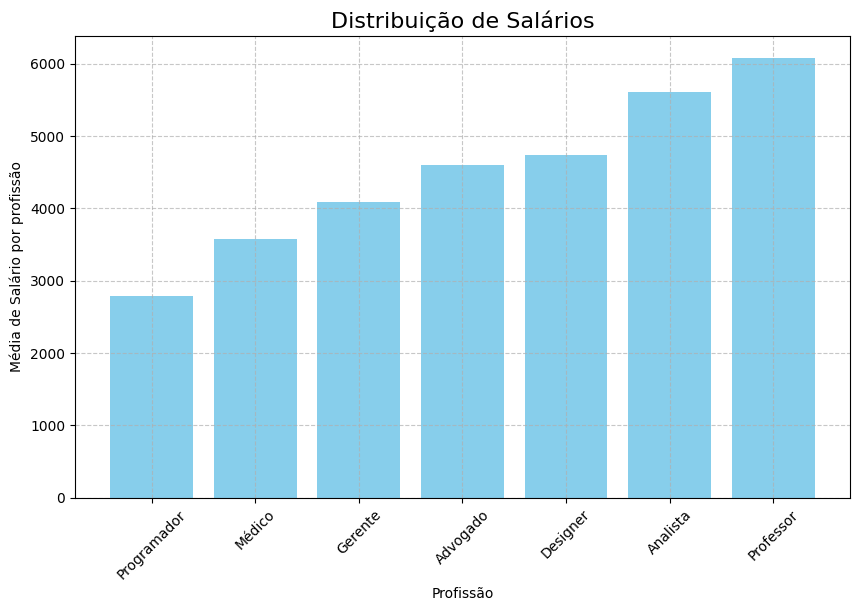

In [5]:
plt.figure(figsize=(10, 6)) # Configurar o tamanho da figura
salario_por_profissao = df.groupby('Profissão')['Salário'].mean().sort_values() #Agrupar os dados por profissao e Calcular a média de salário por profissão 
plt.bar(salario_por_profissao.index, salario_por_profissao, color='skyblue') # índices no eixo x e salários no eixo y
plt.title('Distribuição de Salários', fontsize=16) # Título do gráfico e tamanho da fonte
plt.xlabel('Profissão')
plt.ylabel('Média de Salário por profissão')
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo x em 45 graus
plt.grid(True, linestyle='--', alpha=0.7) # Adicionar uma grade ao gráfico com estilo de linha tracejada (--) e transparência de 70%

2 - Gráfico de linha

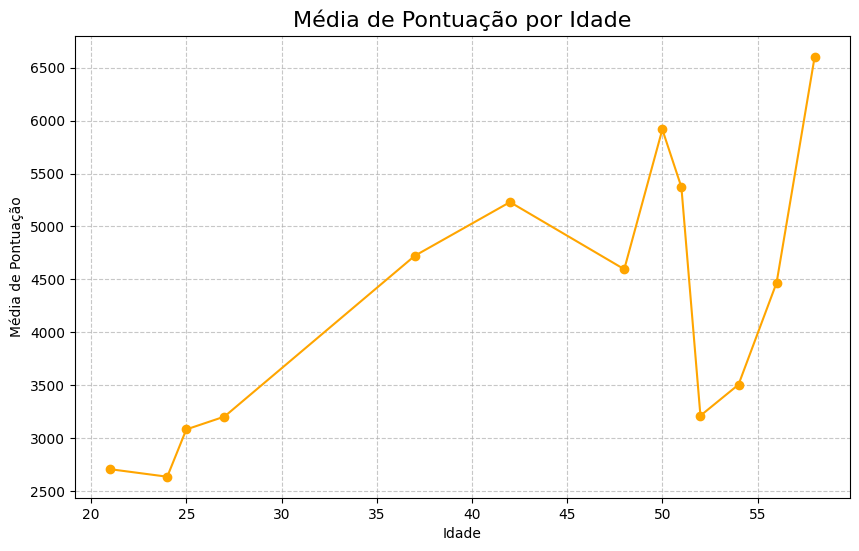

In [6]:
media_score_por_idade = df.groupby('Idade')['Pontuação'].mean() # Agrupar os dados por idade e calcular a média de pontuação por idade
media_score_por_idade = media_score_por_idade.sort_index() # Ordenar os índices (idades) em ordem crescente para garantir que o gráfico seja plotado corretamente
plt.figure(figsize=(10, 6)) # Configurar o tamanho da figura
plt.plot(media_score_por_idade.index, media_score_por_idade, marker='o', color='orange') #marker especifica que os pontos vão ser marcados com círculos ('o')
plt.title('Média de Pontuação por Idade', fontsize=16) 
plt.xlabel('Idade')
plt.ylabel('Média de Pontuação')
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()


3 - Gráficos de linhas e colunas

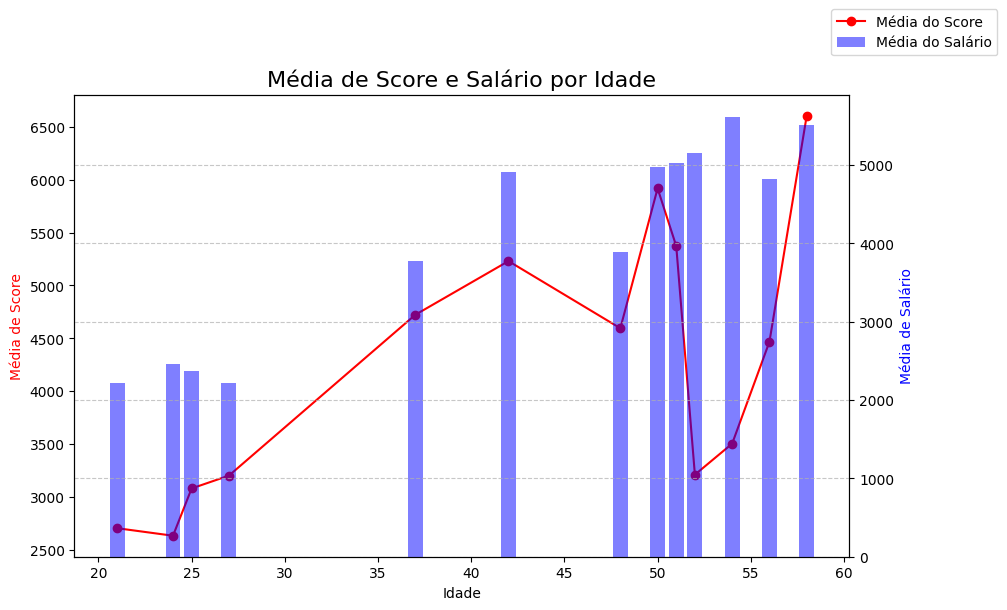

In [7]:
#Calculando média de salário para cada idade
media_salario_por_idade = df.groupby('Idade')['Salário'].mean() # Agrupar os dados por idade e calcular a média de salário por idade

#Ordenando as idades em ordem crescente
media_salario_por_idade = media_salario_por_idade.sort_index() # Ordenar os índices (idades) em ordem crescente para garantir que o gráfico seja plotado corretamente

#Criando o gráfico de linha
fig, ax1 = plt.subplots(figsize=(10, 6)) # Criar uma figura e um eixo para o gráfico

#Plotando a média do score por idade
ax1.plot(media_score_por_idade.index, media_score_por_idade, marker='o', color='red', label='Média do Score') # Plotar o gráfico de linha com marcadores
ax1.set_xlabel('Idade') # Configurar o rótulo do eixo x
ax1.set_ylabel('Média de Score', color='red') # Configurar o rótulo do eixo y para salário e a cor do texto

#Adicionando uma segunda coluna para a média de salário por idade, essa etapa é a configuração do gráfico de barras
ax2 = ax1.twinx() # Criar um segundo eixo y compartilhando o mesmo eixo x
ax2.bar(media_salario_por_idade.index, media_salario_por_idade, color='blue', alpha=0.5, label='Média do Salário') # Plotar o gráfico de barras para salário
ax2.set_ylabel('Média de Salário', color='blue') # Configurar o rótulo do segundo eixo y para salário e a cor do texto

#Legendas:
#Obtendo as linhas e rótulos da legenda do primeiro eixo y(ax1)
lines_1, labels_1 = ax1.get_legend_handles_labels()
#Obtendo as linhas e rótulos da legenda do segundo eixo y(ax2)
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', bbox_to_anchor=(1.2, 1.2)) # Combinar as legendas dos dois gráficos e posicionar no canto superior esquerdo, bbox_to_anchor é usado para ajustar a posição da legenda fora do gráfico, nesse caso, 1.2 unidades à direita e 1.2 unidades para cima do canto superior esquerdo do gráfico.
#labels1 + labels2 concatena os rótulos das legendas dos dois eixos y
#loc= upper right especifica que a legenda será posicionada no canto superior direito

plt.title('Média de Score e Salário por Idade', fontsize=16) # Título do gráfico
plt.grid(True, linestyle='--', alpha=0.7) # Adicionar uma grade
plt.show()

4 - Gráfico de dispersão

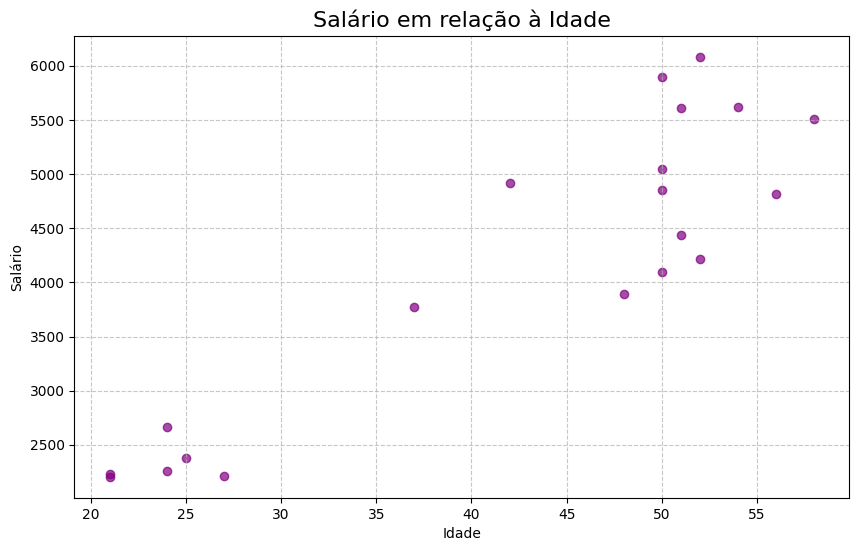

In [8]:
#Criando um gráfico de dispersão de salário em relação á idade
plt.figure(figsize=(10, 6)) # Configurar o tamanho da figura
plt.scatter(df['Idade'], df['Salário'], color='purple', alpha=0.7) # Criar um gráfico de dispersão com idades no eixo x e salários no eixo y

#Adicionando legendas e rótulos
plt.title('Salário em relação à Idade', fontsize=16) 
plt.xlabel('Idade') 
plt.ylabel('Salário') 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

5 - Boxplot

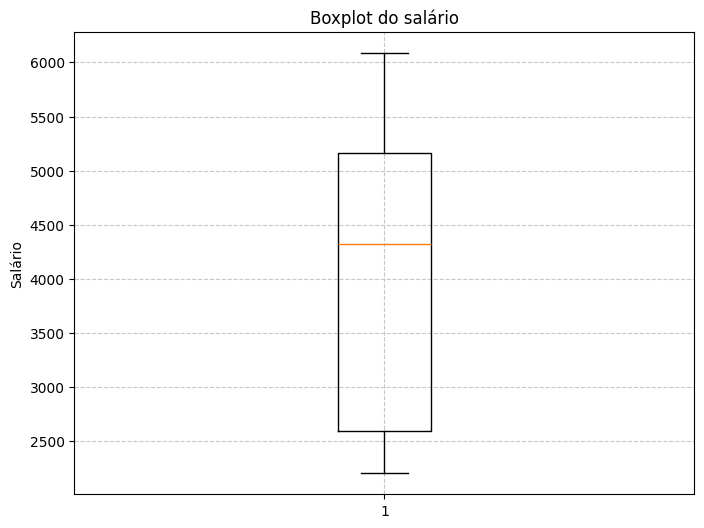

In [9]:
#Criando o boxplot apenas para a coluna do salário
plt.figure(figsize=(8, 6))
plt.boxplot(df['Salário'])

#LEgendas e rótulos
plt.title('Boxplot do salário')
plt.ylabel('Salário')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()